## Radar Emitter Recognition Based on Spiking Neural Networks

Code below base on paper


Simplified Experiment (Python/Math): Simulating one single LIF neuron using numpy. Feeding it two different "radar" spike trains (one fast, one slow) and show that its output firing rate is different.

Radar 1 (10ms PRI) caused 10 output spikes.
Radar 2 (20ms PRI) caused 0 output spikes.


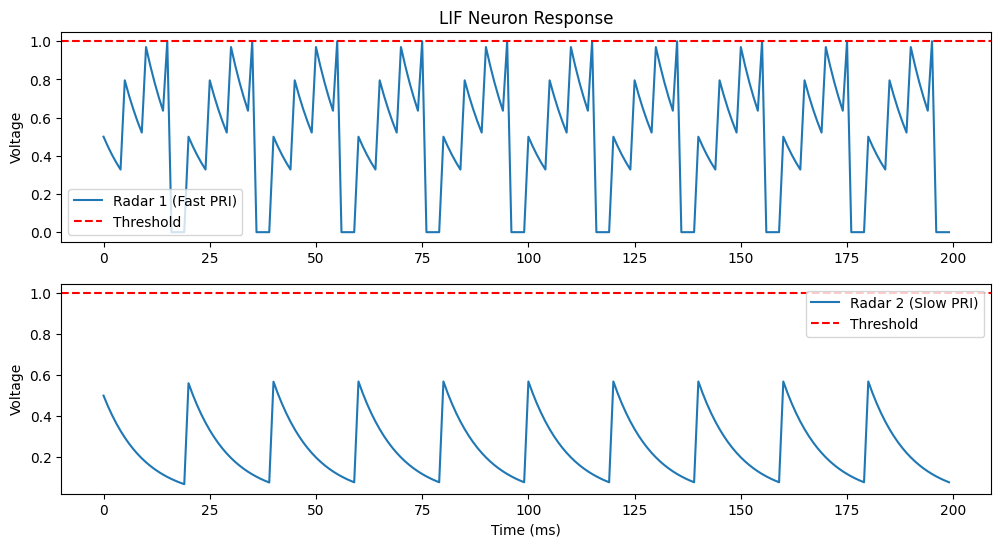

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
T = 200         # Total time steps (ms)
dt = 1          # Time step (ms)
tau_m = 10      # Membrane time constant (ms) -> defines the "leak"
v_thresh = 1.0  # Spike threshold
v_reset = 0.0   # Reset voltage
input_weight = 0.5 # How much a spike "adds"

# --- Input Spike Trains (Simulating 2 Radars) ---
# Radar 1: Fires every 5ms (200 Hz)
spikes_radar1 = np.zeros(T)
spikes_radar1[::5] = 1

# Radar 2: Fires every 20ms (50 Hz)
spikes_radar2 = np.zeros(T)
spikes_radar2[::20] = 1

def simulate_lif(input_spikes):
    v = v_reset  # Start at reset
    v_trace = []
    output_spikes = []

    for t in range(T):
        # 1. Apply the leak (Euler method)
        v = v + ((-v / tau_m) * dt)

        # 2. Add input spike (Integrate)
        if input_spikes[t] == 1:
            v = v + input_weight

        # 3. Check for fire
        if v > v_thresh:
            v = v_reset  # Reset
            output_spikes.append(t)
            v_trace.append(v_thresh) # For plotting
        else:
            v_trace.append(v)

        # Prevent voltage from going negative (optional)
        v = max(v_reset, v)

    return v_trace, output_spikes

# --- Run Simulation ---
v1, out1 = simulate_lif(spikes_radar1)
v2, out2 = simulate_lif(spikes_radar2)

print(f"Radar 1 (10ms PRI) caused {len(out1)} output spikes.")
print(f"Radar 2 (20ms PRI) caused {len(out2)} output spikes.")

# --- Plot ---
plt.figure(figsize=(12, 6))
plt.subplot(2,1,1)
plt.plot(v1, label='Radar 1 (Fast PRI)')
plt.axhline(v_thresh, color='r', linestyle='--', label='Threshold')
plt.title('LIF Neuron Response')
plt.legend()
plt.ylabel('Voltage')

plt.subplot(2,1,2)
plt.plot(v2, label='Radar 2 (Slow PRI)')
plt.axhline(v_thresh, color='r', linestyle='--', label='Threshold')
plt.legend()
plt.xlabel('Time (ms)')
plt.ylabel('Voltage')
plt.show()

## Bat echolocation processing using first-spike latency coding

Simplified Experiment (Python/Math): Simulate this encoding. Forget the leak for a moment and just "integrate" (sum) two different signals. Show that the stronger one crosses a threshold first.

Weak Signal (Far Object) FSL: 20 time steps
Strong Signal (Near Object) FSL: 6 time steps


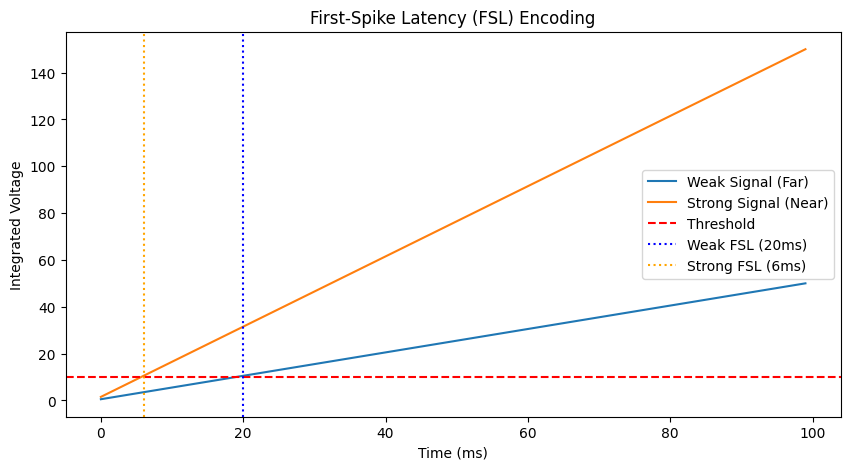

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
T = 100         # Time steps
threshold = 10.0 # Arbitrary threshold

# --- Input Signals (Simulating Echoes) ---
# Weak echo (e.g., far object)
signal_weak = np.ones(T) * 0.5

# Strong echo (e.g., near object)
signal_strong = np.ones(T) * 1.5

# --- Simulate "integrator" neurons ---
# np.cumsum performs the integration (summing up over time)
v_weak = np.cumsum(signal_weak)
v_strong = np.cumsum(signal_strong)

# --- Find First-Spike Latency ---
# np.argmax finds the *first* index where the condition is True
try:
    latency_weak = np.argmax(v_weak > threshold)
except ValueError:
    latency_weak = -1 # Did not fire

try:
    latency_strong = np.argmax(v_strong > threshold)
except ValueError:
    latency_strong = -1 # Did not fire

print(f"Weak Signal (Far Object) FSL: {latency_weak} time steps")
print(f"Strong Signal (Near Object) FSL: {latency_strong} time steps")

# --- Plot ---
plt.figure(figsize=(10, 5))
plt.plot(v_weak, label='Weak Signal (Far)')
plt.plot(v_strong, label='Strong Signal (Near)')
plt.axhline(threshold, color='r', linestyle='--', label='Threshold')
plt.axvline(latency_weak, color='blue', linestyle=':', label=f'Weak FSL ({latency_weak}ms)')
plt.axvline(latency_strong, color='orange', linestyle=':', label=f'Strong FSL ({latency_strong}ms)')
plt.title('First-Spike Latency (FSL) Encoding')
plt.xlabel('Time (ms)')
plt.ylabel('Integrated Voltage')
plt.legend()
plt.show()

## Efficient and Robust Spiking Neural Circuit for Navigation...

Simplified Experiment (Python/Math): Simulate the sensor model (the "front end") that feeds the SNN. You don't need the SNN itself. Just show how to generate the error signal.

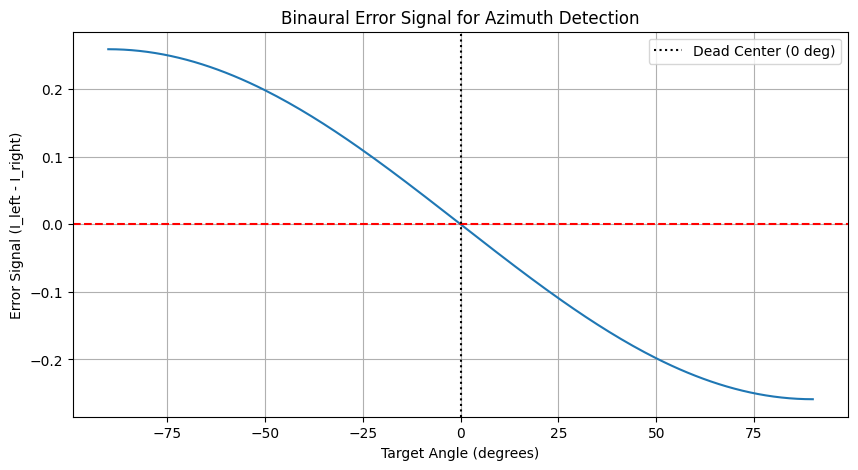

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- Sensor Mechanism ---
# Cardioid function: g(theta) = 0.5 * (1 + cos(theta))
# It's 1 at 0 degrees (front), 0.5 at 90 deg (side), 0 at 180 deg (back)
def cardioid_gain(angle_deg):
    angle_rad = np.deg2rad(angle_deg)
    return 0.5 * (1 + np.cos(angle_rad))

# --- Simulate ---
# Angle of the two "ears" relative to the head (e.g., 30 deg apart)
left_ear_angle = -15
right_ear_angle = 15

target_angles = np.linspace(-90, 90, 181) # Sweep target from left to right
error_signals = []

for target_angle in target_angles:
    # Calculate angle of target *relative to each ear*
    relative_angle_left = target_angle - left_ear_angle
    relative_angle_right = target_angle - right_ear_angle

    # Calculate intensity at each ear
    intensity_left = cardioid_gain(relative_angle_left)
    intensity_right = cardioid_gain(relative_angle_right)

    # The "error signal" is the difference
    error = intensity_left - intensity_right
    error_signals.append(error)

# --- Plot ---
plt.figure(figsize=(10, 5))
plt.plot(target_angles, error_signals)
plt.axhline(0, color='r', linestyle='--')
plt.axvline(0, color='k', linestyle=':', label='Dead Center (0 deg)')
plt.title('Binaural Error Signal for Azimuth Detection')
plt.xlabel('Target Angle (degrees)')
plt.ylabel('Error Signal (I_left - I_right)')
plt.grid(True)
plt.legend()
plt.show()

## Computing with Neural Synchrony

Simplified Experiment (Python/Math): This is harder to code, but we can simulate the concept. Simulate two different filters (neurons) and show that we can find an input signal that makes their outputs peak at the same time.

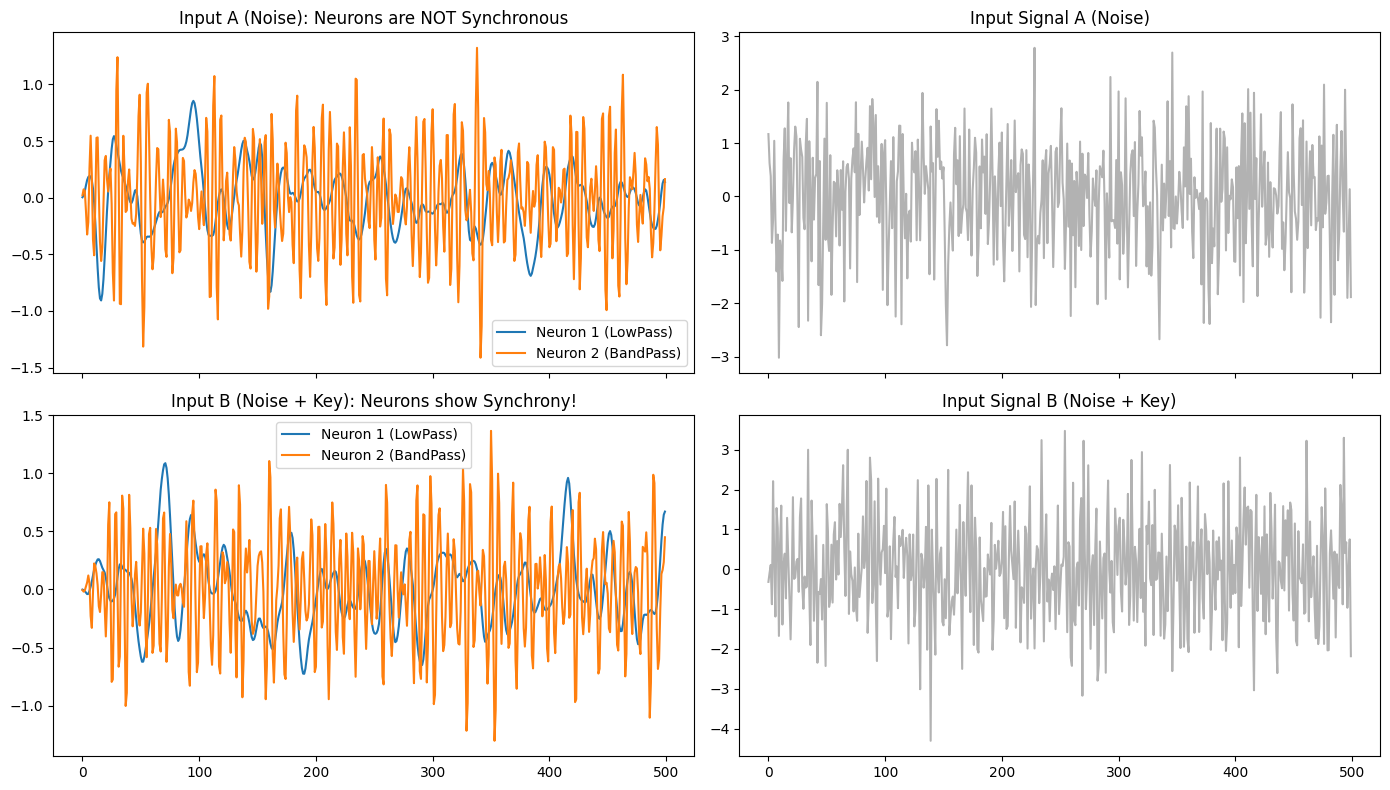

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter

# 1. Create two "heterogeneous neurons" (i.e., different filters)
# Neuron 1: A low-pass filter
b1, a1 = butter(3, 0.1, btype='low')

# Neuron 2: A band-pass filter
b2, a2 = butter(3, [0.2, 0.4], btype='band')

# 2. Create input signals
T = 500
t = np.arange(T)

# Input Signal A: Just white noise
input_A = np.random.randn(T)

# Input Signal B: White noise + a specific "key" frequency
# This is our "Synchrony Receptive Field"
key_signal = np.sin(2 * np.pi * 0.3 * t) # 0.3 is in the bandpass
input_B = np.random.randn(T) + key_signal

# 3. Pass signals through "neurons"
out_A1 = lfilter(b1, a1, input_A)
out_A2 = lfilter(b2, a2, input_A)

out_B1 = lfilter(b1, a1, input_B)
out_B2 = lfilter(b2, a2, input_B)

# 4. Plot the results
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

ax1.plot(out_A1, label='Neuron 1 (LowPass)')
ax1.plot(out_A2, label='Neuron 2 (BandPass)')
ax1.set_title('Input A (Noise): Neurons are NOT Synchronous')
ax1.legend()

ax2.plot(t, input_A, color='k', alpha=0.3)
ax2.set_title('Input Signal A (Noise)')

ax3.plot(out_B1, label='Neuron 1 (LowPass)')
ax3.plot(out_B2, label='Neuron 2 (BandPass)')
ax3.set_title('Input B (Noise + Key): Neurons show Synchrony!')
ax3.legend()

ax4.plot(t, input_B, color='k', alpha=0.3)
ax4.set_title('Input Signal B (Noise + Key)')

plt.tight_layout()
plt.show()